In [89]:
from scipy import integrate 
import numpy as np
import matplotlib.pyplot as plt 

### part 1

<small>

complex plane $c = x+iy$ with $-2<x<2$ and $-2<y<2$ set to $z_0=0$ and iterate through $z_{i+1} = z_{i}^2+c$, some $z_i$'s are bounded in $| \Re (z)^2 + \Im (z)^2|$ while others run off to infinity


make an image in which your points $c$ that diverge are given one color and those that stay bounded are given another

make a second image where the points are colored by a colorscalee that indicates the iteration number at which the point diverged

</small>

Text(0.5, 1.0, 'Diverging')

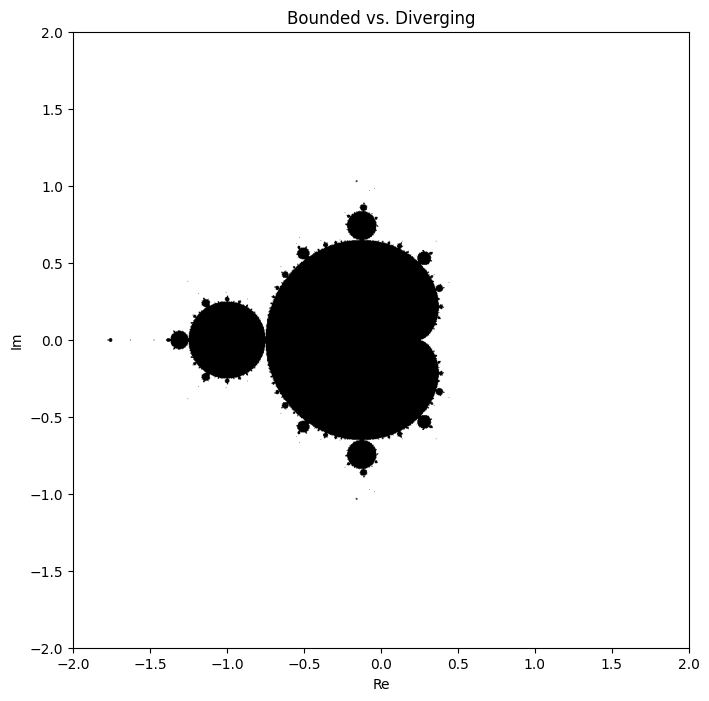

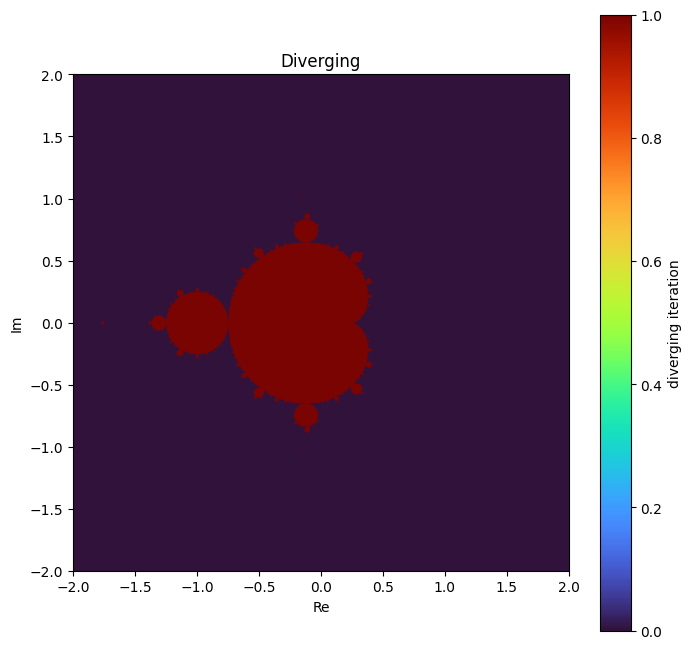

In [90]:

# %run -i a3.py
import a3

bounded, diverging = a3.smth()

# first image
plt.figure(figsize=(8,8))
plt.imshow(bounded, extent=(-2,2,-2,2), origin='lower', cmap='binary')

plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Bounded vs. Diverging")

# second image
plt.figure(figsize=(8,8))
plt.imshow(bounded, extent=(-2,2,-2,2), origin='lower', cmap='turbo')
plt.colorbar(label='diverging iteration')

plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Diverging")


all one color not sure what happened

### part 2

<small>

Lorenz's equations: https://journals.ametsoc.org/view/journals/atsc/20/2/1520-0469_1963_020_0130_dnf_2_0_co_2.xml

$\dot X = - \sigma (X-Y) $

$\dot Y = -  rX-Y-XZ $

$\dot Z = - \sigma (-bZ+XY) $

$\sigma$ is prandtl number, $r$ is rayleigh number, and $b$ is dimensionless length scale

1. code up equations with docstrings
2. use an ode solver ex. `solve_ivp` or `ode` to integrate the equations for $t=60$. use lorenz'z initial conditions $W_O = [0.,1.,0.]$ and parameter values $[\sigma, r, b] = [10., 28, 8./3.]$
(look at further insrtructions for these in pdf)
3. reproduce lorenz's Figure 1, label both axes
4. reproduce lorenz's Figure 2
5. ... more when done above


In [91]:
# equation
def lorenz(t, W, prandtl, rayleigh, b):
    X, Y, Z = W
    dxdt = -(prandtl)*(X-Y)
    dydt = rayleigh*X - Y - X*Z
    dzdt = -b*Z+X*Y
    return (dxdt, dydt, dzdt)


In [92]:
# parameters
W0 = (0.0, 1.0, 0.0)
prandtl = 10.0
r = 28.0
b = 8.0/3.0
t_span = (0.0, 60.0) # solve from t=0-60

# FIXME - why
t_eval = np.linspace(0, 60.0, 3000) # sol sampled at 3000 evenly spaced times


#  integrate equations 
integral = integrate.solve_ivp(lorenz, t_span, W0, args=(prandtl, r, b), t_eval=t_eval)

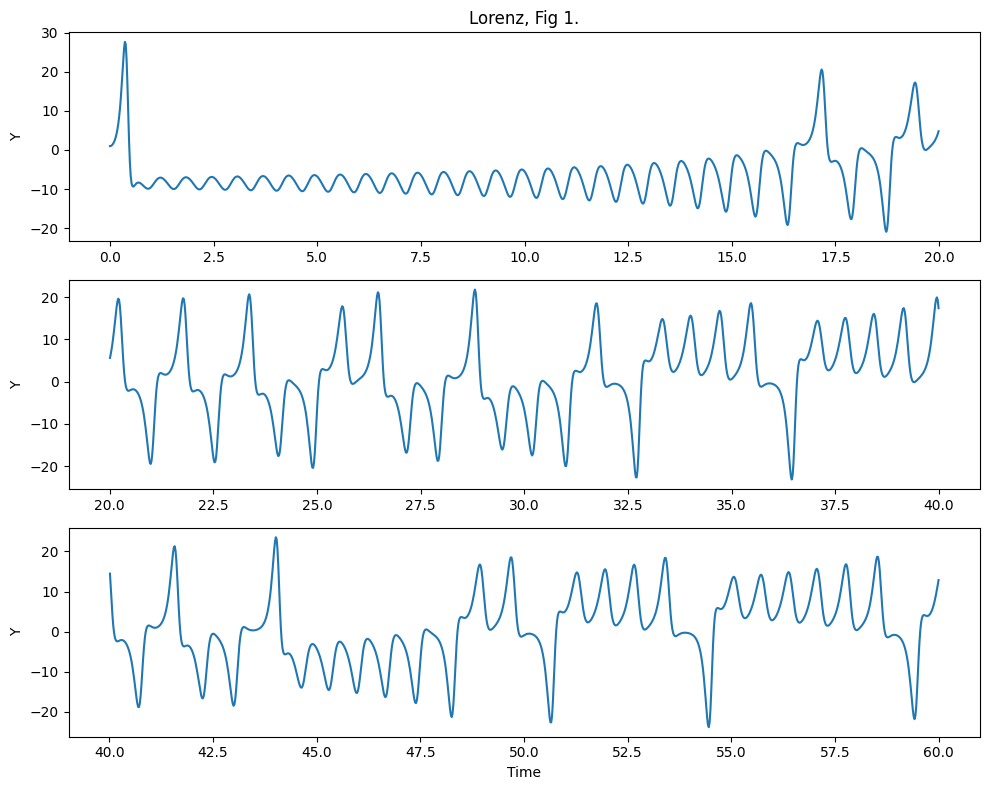

In [93]:
# make figure 1

t = integral.t
x = integral.y[0]
y = integral.y[1] # index 1 contains y
z = integral.y[2]

# stacked plots
fig, ax = plt.subplots(3,1,figsize=(10,8))

ax[0].set_title("Lorenz, Fig 1.")


ax[0].plot(t[:1000], y[:1000]) # 1000 iter
ax[0].set_ylabel("Y")
ax[1].plot(t[1000:2000], y[1000:2000]) # 1000 iter
ax[1].set_ylabel("Y")
ax[2].plot(t[2000:3000], y[2000:3000]) # 1000 iter
ax[2].set_ylabel("Y")
ax[2].set_xlabel("Time")

plt.tight_layout()
plt.show()



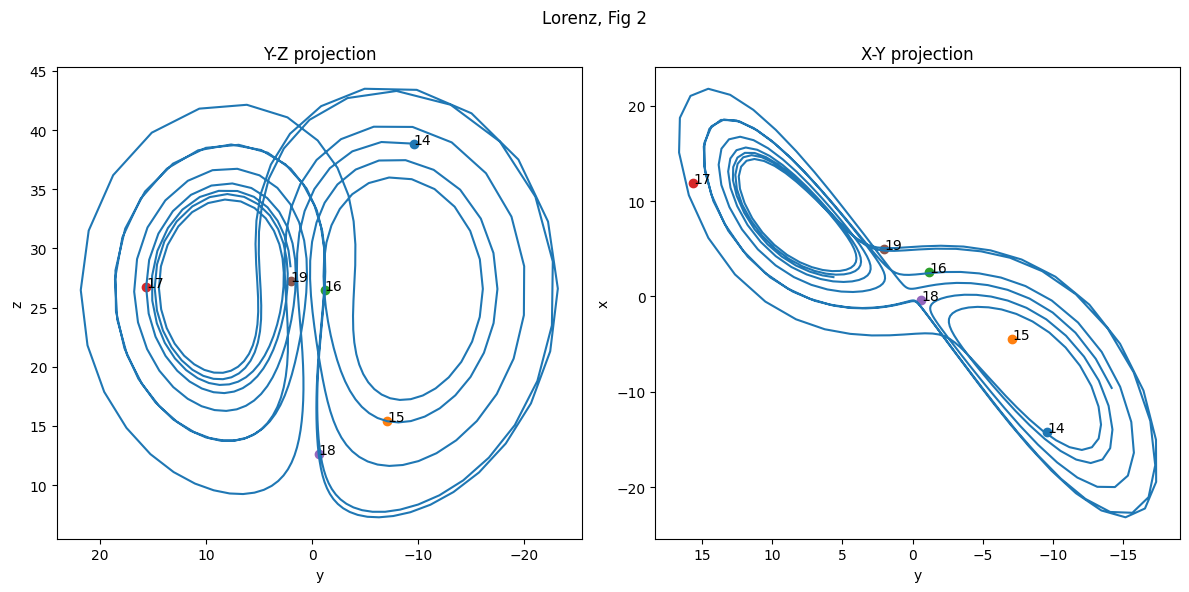

In [94]:
# make figure 2

start, stop = 1400, 1900

annotations = range(1400, 1901, 100) # start, stop not included, interval

fig, ax = plt.subplots(1,2,figsize=(12,6))

fig.suptitle("Lorenz, Fig 2")

# first part - YZ-projection
ax[0].plot(y[start:stop], z[start:stop])
for i in annotations:
    ax[0].scatter(y[i], z[i])
    ax[0].text(y[i], z[i], str(i//100))
    # ax[0].scatter(z[i], y[i])
    # ax[0].text(z[i], y[i], str(i))

ax[0].set_xlabel("y")
ax[0].set_ylabel("z")
ax[0].set_title("Y-Z projection")
ax[0].invert_xaxis()

# second part - XY-projection
ax[1].plot(x[start:stop], y[start:stop])

for i in annotations:
    ax[1].scatter(y[i], x[i])
    ax[1].text(y[i], x[i], str(i//100))

ax[1].set_xlabel("y")
ax[1].set_ylabel("x")
ax[1].set_title("X-Y projection")
ax[1].invert_xaxis()



plt.tight_layout()
plt.show()



i inverted the x-axes to match lorenz, is that right

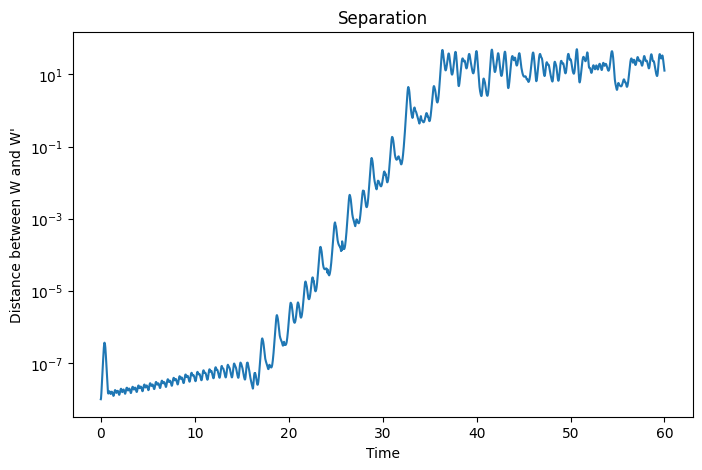

In [95]:
# final plot

W0_prime = np.asarray(W0) + np.asarray([0, 1e-8, 0])

# solve again
integral2 = integrate.solve_ivp(lorenz, t_span, W0_prime, args=(prandtl, r, b), t_eval=t_eval)

# distances
pos1 = integral.y.T
pos2 = integral2.y.T

posx, posy, posz = (pos2-pos1).T # transpose to unpack x,y,z differences
distance = np.sqrt((posx**2+posy**2+posz**2))

# plot figure 
plt.figure(figsize=(8,5))
plt.semilogy(integral.t, distance)

plt.title("Separation")
plt.xlabel("Time")
plt.ylabel("Distance between W and W'")
plt.show()



In [96]:
import os
print(os.getcwd())
print(os.listdir())

import a3
print(a3.__file__)
print(a3)

c:\Users\amani\Downloads\SURP\actually_cta
['a3.py', 'assignment.ipynb', 'assignment2.ipynb', 'assignment3.ipynb', 'assignment3.tex', 'assignment_3.pdf', 'atsc-1520-0469_1963_020_0130_dnf_2_0_co_2.pdf', '__pycache__']
c:\Users\amani\Downloads\SURP\actually_cta\a3.py
<module 'a3' from 'c:\\Users\\amani\\Downloads\\SURP\\actually_cta\\a3.py'>
